# Team 7 — Code Avengers | Category2 : Descriptive Analysis

In [53]:
# Install Seaborn if needed.

!pip install pandas numpy matplotlib seaborn plotly

#Install Advanced Visualisation Libraries
!pip install bokeh altair holoviews hvplot
!pip install networkx squarify wordcloud
!pip install scipy statsmodels scikit-learn

!pip install streamlit
!pip install dash dash-bootstrap-components
!pip install panel

In [56]:
# ============================================================
# IMPORT ALL NECESSARY LIBRARIES
# ============================================================

# Data Handling
import pandas as pd
import numpy as np

# File & System Utilities
import os
import json
import warnings
from pathlib import Path

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical Analysis
from scipy.stats import spearmanr, mannwhitneyu

# Advanced Visualization
import networkx as nx
import squarify
from wordcloud import WordCloud

# Dashboarding
import streamlit as st
import dash
import panel as pn

# Warning Settings
warnings.filterwarnings("ignore")

In [57]:
# ============================================================
# SHARED DATA PATH AND DATASET LOADING
# ============================================================
from pathlib import Path
import pandas as pd

BASE_URL = (
    "https://raw.githubusercontent.com/"
    "kamsandhya-cyber/Team7_CodeAvengers_PythonHackathon_SEP2026/main/cleaned_data/"
)

<p style="font-family: Cambria; font-size: 20px;"><b>Read the Datasets</b></p>

In [58]:
# Read the original Demography dataset
demo = pd.read_csv(BASE_URL + "Team7_CodeAvengers_Category1_DataCleaning_demography.csv")
labs = pd.read_csv(BASE_URL + "Team7_CodeAvengers_Category1_DataCleaning_labs.csv")
cc = pd.read_csv(BASE_URL + "Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv")
resp = pd.read_csv(BASE_URL + "Team7_CodeAvengers_Category1_DataCleaning_responsivenes.csv")
pp = pd.read_csv(BASE_URL + "Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv")
ph = pd.read_csv(BASE_URL +"Team7_CodeAvengers_Category1_DataCleaning_patienthistory_cleaned.csv")
hd = pd.read_csv(BASE_URL +"Team7_CodeAvengers_Category1_DataCleaning_hospitalization_discharge.csv")

# Demography : Display the first five records
print("Demography Table")
display(demo.head())

# Responsivenes :  Display the first five records
print("Responsivees Table")
display(resp.head())

# Labs : Display the first five records
print("Labs Table")
display(labs.head())

# Cardiac Condition : Display the first five records
print("Cardiac Condition Table")
display(cc.head())

# Patients Prescription : Display the first five records
print("Patients Prescription Table")
display(pp.head())

# Patient History : Display the first five records
print("Patients History Table")
display(ph.head())

# Hospitalization Discharge : Display the first five records
print("Patients History Table")
display(hd.head())



Demography Table


,inpatient_number,gender,weight,height,bmi,occupation,agecat
0,827040,Female,50.0,1.45,23.781213,Unknown,69-79
1,857781,Male,50.0,1.64,18.590125,UrbanResident,69-79
2,743087,Female,51.0,1.63,19.195303,UrbanResident,69-79
3,866418,Male,70.0,1.70,24.221453,farmer,59-69
4,775928,Male,65.0,1.70,22.491349,UrbanResident,69-79


Responsivees Table


,inpatient_number,eye_opening,verbal_response,movement,consciousness,gcs
0,857781,4,5,6,Clear,15
1,743087,4,5,6,Clear,15
2,866418,4,5,6,Clear,15
3,775928,4,5,6,Clear,15
4,810128,4,5,6,Clear,15


Labs Table


...

,inpatient_number,drug_name
0,857781,Sulfotanshinone sodium injection
1,857781,Furosemide tablet
2,857781,Enoxaparin Sodium injection
3,857781,Meglumine Adenosine Cyclophosphate for injection
4,857781,Furosemide injection


Patients History Table


,inpatient_number,cerebrovascular_disease,dementia,chronic_obstructive_pulmonary_disease,connective_tissue_disease,peptic_ulcer_disease,diabetes,moderate_to_severe_chronic_kidney_disease,hemiplegia,leukemia,malignant_lymphoma,solid_tumor,liver_disease,aids,cci_score,type_ii_respiratory_failure,acute_renal_failure
0,857781,0,0,1,0,0.0,1,0.0,0,0,0,0,0.0,0,2.0,nontypeii,0
1,743087,0,0,0,0,0.0,0,0.0,0,0,0,0,0.0,0,0.0,nontypeii,0
2,866418,0,0,0,0,0.0,0,0.0,0,0,0,0,0.0,0,0.0,nontypeii,0
3,775928,0,0,1,0,0.0,0,1.0,0,0,0,0,0.0,0,2.0,nontypeii,0
4,810128,0,0,0,0,0.0,0,0.0,0,0,0,0,0.0,0,0.0,nontypeii,0


Patients History Table


,inpatient_number,destinationdischarge,admission_ward,admission_way,discharge_department,visit_times,respiratory_support,oxygen_inhalation,dischargeday,admission_date,...,death_within_28_days,re_admission_within_28_days,death_within_3_months,re_admission_within_3_months,death_within_6_months,re_admission_within_6_months,time_of_death__days_from_admission,readmission_time_days_from_admission,return_to_emergency_department_within_6_months,time_to_emergency_department_within_6_months
0,857781,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,11,2017-01-24,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN
1,743087,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,8,2017-05-05,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN
2,866418,Home,Cardiology,NonEmergency,Cardiology,2,NaN,OxygenTherapy,5,2016-11-18,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN
3,775928,Home,Cardiology,Emergency,Cardiology,1,NaN,OxygenTherapy,11,2017-10-02,...,0,1,0,1,0,1,NaN,19.0,1.0,19.0
4,810128,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,5,2019-11-17,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN


<p style="font-family: Cambria; font-size: 20px;"><b>Question 1 : Which demographic profiles are most commonly associated with abnormal patient responsiveness?</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>This question helps identify whether abnormal responsiveness is more frequently observed in particular demographic groups, such as specific age groups or genders. By comparing these profiles, we can recognize patterns in the patient population and determine which groups have a higher observed count of abnormal responsiveness.</p>

In [59]:
# -------------------------------------------------------
# Step 1. Merge Demography and Responsivenes Tables
# -------------------------------------------------------
df = pd.merge(
    demo,
    resp,
    on="inpatient_number",
    how="inner"
)

print(df.shape)
df.head()

(2008, 12)


,inpatient_number,gender,weight,height,bmi,occupation,agecat,eye_opening,verbal_response,movement,consciousness,gcs
0,827040,Female,50.0,1.45,23.781213,Unknown,69-79,4,5,6,Clear,15
1,857781,Male,50.0,1.64,18.590125,UrbanResident,69-79,4,5,6,Clear,15
2,743087,Female,51.0,1.63,19.195303,UrbanResident,69-79,4,5,6,Clear,15
3,866418,Male,70.0,1.70,24.221453,farmer,59-69,4,5,6,Clear,15
4,775928,Male,65.0,1.70,22.491349,UrbanResident,69-79,4,5,6,Clear,15


Abnormal patients: 34


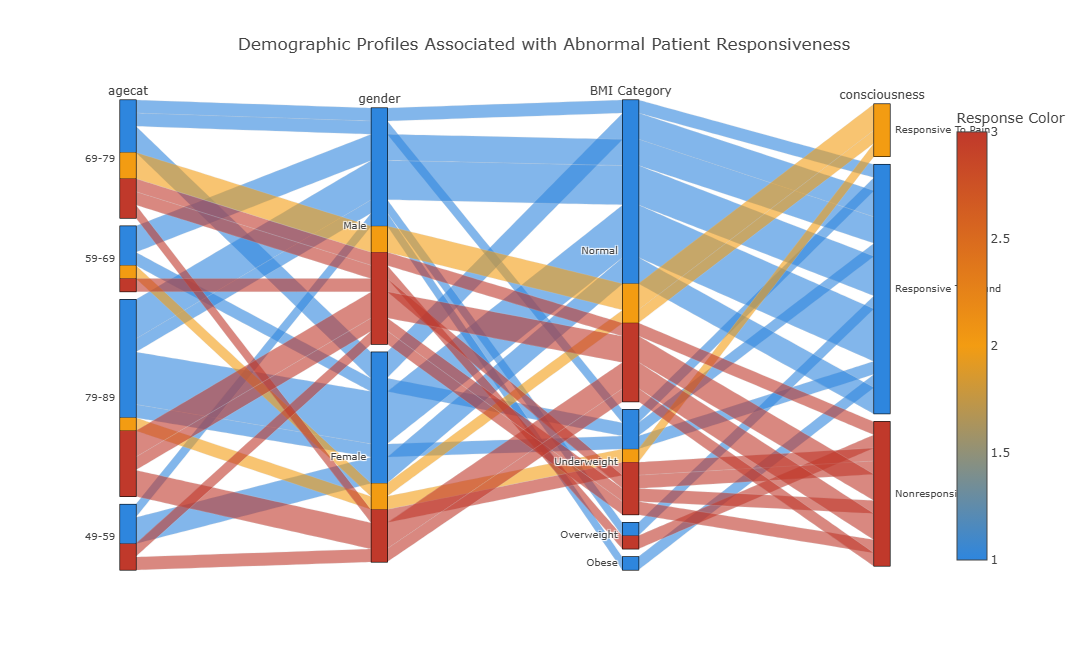

In [60]:
# -------------------------------------------------------
# Step 2. Create Normal vs Abnormal Responsiveness
# -------------------------------------------------------
df["Responsiveness"] = df["consciousness"].apply(
    lambda x: "Normal" if x == "Clear" else "Abnormal"
)

df["Responsiveness"].value_counts()

# -------------------------------------------------------
# Step 3. Create BMI categories
# -------------------------------------------------------
df["BMI Category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, float("inf")],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ]
)

df["BMI Category"].value_counts()

# -------------------------------------------------------
# Step 4. Keep abnormal patients
# -------------------------------------------------------

abnormal_df = df[
    df["Responsiveness"] == "Abnormal"
].copy()

print("Abnormal patients:", len(abnormal_df))

abnormal_df[
    [
        "inpatient_number",
        "agecat",
        "gender",
        "BMI Category",
        "occupation",
        "consciousness"
    ]
].head()

color_map = {
    "Responsive To Sound": 1,
    "Responsive To Pain": 2,
    "Nonresponsive": 3
}

abnormal_df["Response Color"] = abnormal_df["consciousness"].map(color_map)
# -------------------------------------------------------
# Step 5. Create the Parallel Categories chart
# -------------------------------------------------------
fig = px.parallel_categories(
    abnormal_df,
    dimensions=[
        "agecat",
        "gender",
        "BMI Category",
        "consciousness"
    ],
    color="Response Color",
    color_continuous_scale=[
        [0.00, "#2E86DE"],
        [0.50, "#F39C12"],
        [1.00, "#C0392B"]
    ],
    title="Demographic Profiles Associated with Abnormal Patient Responsiveness"
)

fig.update_layout(
    width=1000,
    height=650,
    title_x=0.5,
    font=dict(size=12)
)

fig.show()


<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight : </b>Abnormal responsiveness was most commonly observed among patients aged 79–89, particularly females, indicating that older patients represented the largest demographic group among abnormal-response cases in this dataset.</p>

<p style="font-family: Cambria; font-size: 20px;"><b>Question 2 : How is BNP distributed among patients, and what does the distribution reveal about the concentration and variability of BNP levels?
</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>This question is useful because NYHA class, BNP, and LVEF describe different aspects of cardiac status. NYHA represents functional limitation, BNP is a cardiac biomarker, and LVEF measures ventricular pumping function. Looking at them together helps you explore whether particular functional classes tend to flow toward different BNP and LVEF profiles.</p>

In [61]:
# -------------------------------------------------------
# Step 1. Merge Cardiac Condition and Labs Tables
# -------------------------------------------------------

df = pd.merge(
    labs[
        [
            "inpatient_number",
            "brain_natriuretic_peptide"
        ]
    ],
    cc[
        [
            "inpatient_number",
            "nyha_cardiac_function_classification",
            "lvef"
        ]
    ],
    on="inpatient_number",
    how="inner"
)

,Source,Target,Patients
0,NYHA 2,Lower BNP,23
1,NYHA 2,Middle BNP,9
2,NYHA 2,Higher BNP,4
3,NYHA 3,Lower BNP,124
4,NYHA 3,Middle BNP,123
5,NYHA 3,Higher BNP,86
6,NYHA 4,Lower BNP,62
7,NYHA 4,Middle BNP,76
8,NYHA 4,Higher BNP,119
9,Lower BNP,Lower LVEF,23


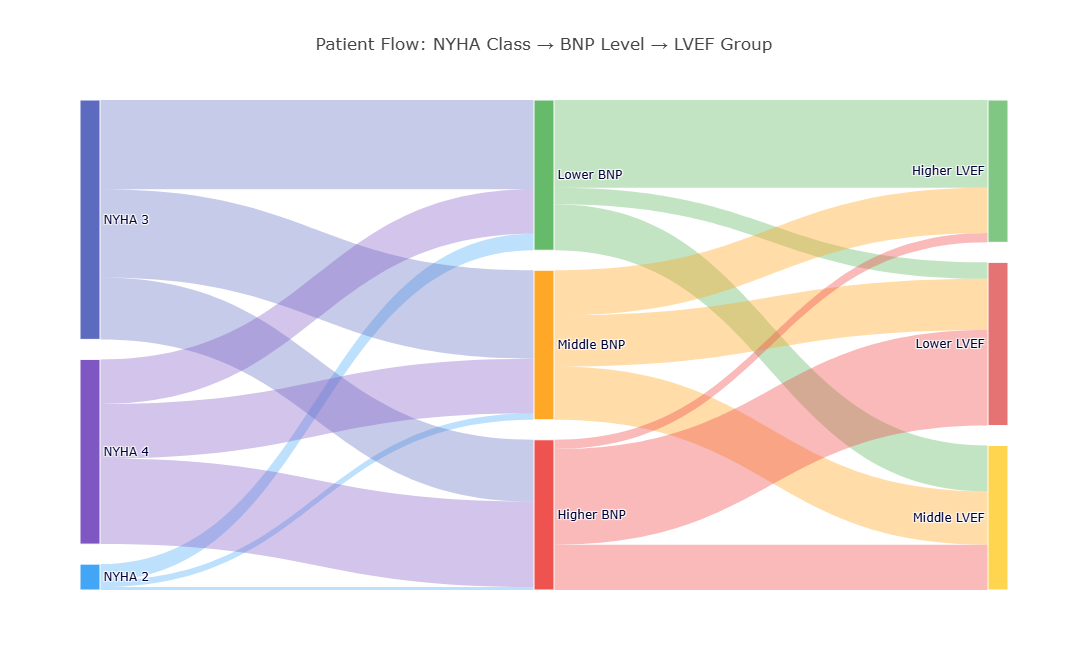

In [62]:
# ------------------------------------------------------------
# Step 2. Convert BNP and LVEF to numeric
# ------------------------------------------------------------

df["brain_natriuretic_peptide"] = pd.to_numeric(
    df["brain_natriuretic_peptide"],
    errors="coerce"
)

df["lvef"] = pd.to_numeric(
    df["lvef"],
    errors="coerce"
)

df = df.dropna(
    subset=[
        "brain_natriuretic_peptide",
        "lvef",
        "nyha_cardiac_function_classification"
    ]
)


# ------------------------------------------------------------
# Step 3. Create BNP categories
# ------------------------------------------------------------

df["BNP_Category"] = pd.qcut(
    df["brain_natriuretic_peptide"],
    q=3,
    labels=[
        "Lower BNP",
        "Middle BNP",
        "Higher BNP"
    ],
    duplicates="drop"
)


# ------------------------------------------------------------
# Step 4. Create LVEF categories
# ------------------------------------------------------------

df["LVEF_Category"] = pd.qcut(
    df["lvef"],
    q=3,
    labels=[
        "Lower LVEF",
        "Middle LVEF",
        "Higher LVEF"
    ],
    duplicates="drop"
)


# ------------------------------------------------------------
# Step 5. Prepare NYHA → BNP flow
# ------------------------------------------------------------

flow1 = (
    df.groupby(
        [
            "nyha_cardiac_function_classification",
            "BNP_Category"
        ],
        observed=True
    )
    .size()
    .reset_index(name="Patients")
)

flow1["Source"] = (
    "NYHA "
    + flow1[
        "nyha_cardiac_function_classification"
    ].astype(str)
)

flow1["Target"] = (
    flow1["BNP_Category"].astype(str)
)


# ------------------------------------------------------------
# Step 6. Prepare BNP → LVEF flow
# ------------------------------------------------------------

flow2 = (
    df.groupby(
        [
            "BNP_Category",
            "LVEF_Category"
        ],
        observed=True
    )
    .size()
    .reset_index(name="Patients")
)

flow2["Source"] = (
    flow2["BNP_Category"].astype(str)
)

flow2["Target"] = (
    flow2["LVEF_Category"].astype(str)
)


# ------------------------------------------------------------
# Step 7. Combine flows
# ------------------------------------------------------------

flows = pd.concat(
    [
        flow1[["Source", "Target", "Patients"]],
        flow2[["Source", "Target", "Patients"]]
    ],
    ignore_index=True
)

display(flows)


# ------------------------------------------------------------
# Step 8. Create Sankey nodes
# ------------------------------------------------------------

nodes = list(
    pd.unique(
        flows[["Source", "Target"]].values.ravel()
    )
)

node_index = {
    node: i
    for i, node in enumerate(nodes)
}

flows["source_id"] = (
    flows["Source"].map(node_index)
)

flows["target_id"] = (
    flows["Target"].map(node_index)
)


# ------------------------------------------------------------
# Step 9. ADD COLORS
# ------------------------------------------------------------

color_map = {

    # NYHA Classes
    "NYHA 1": "#90CAF9",
    "NYHA 2": "#42A5F5",
    "NYHA 3": "#5C6BC0",
    "NYHA 4": "#7E57C2",

    # BNP Categories
    "Lower BNP": "#66BB6A",
    "Middle BNP": "#FFA726",
    "Higher BNP": "#EF5350",

    # LVEF Categories
    "Lower LVEF": "#E57373",
    "Middle LVEF": "#FFD54F",
    "Higher LVEF": "#81C784"
}


# Assign colors to nodes
node_colors = [
    color_map.get(node, "#BDBDBD")
    for node in nodes
]


# ------------------------------------------------------------
# Step 10. Add transparent colors to flows
# ------------------------------------------------------------

link_color_map = {

    # NYHA flows
    "NYHA 1": "rgba(144,202,249,0.35)",
    "NYHA 2": "rgba(66,165,245,0.35)",
    "NYHA 3": "rgba(92,107,192,0.35)",
    "NYHA 4": "rgba(126,87,194,0.35)",

    # BNP flows
    "Lower BNP": "rgba(102,187,106,0.40)",
    "Middle BNP": "rgba(255,167,38,0.40)",
    "Higher BNP": "rgba(239,83,80,0.40)"
}


link_colors = [
    link_color_map.get(
        source,
        "rgba(180,180,180,0.30)"
    )
    for source in flows["Source"]
]


# ------------------------------------------------------------
# Step 11. Create Colored Sankey Chart
# ------------------------------------------------------------

fig = go.Figure(
    data=[
        go.Sankey(

            arrangement="snap",

            node=dict(
                pad=20,
                thickness=20,

                line=dict(
                    color="white",
                    width=1
                ),

                label=nodes,

                # NODE COLORS
                color=node_colors
            ),

            link=dict(

                source=flows["source_id"],

                target=flows["target_id"],

                value=flows["Patients"],

                # FLOW COLORS
                color=link_colors
            )
        )
    ]
)


# ------------------------------------------------------------
# Step 12. Chart formatting
# ------------------------------------------------------------

fig.update_layout(

    title=dict(
        text=(
            "Patient Flow: NYHA Class → "
            "BNP Level → LVEF Group"
        ),
        x=0.5,
        xanchor="center"
    ),

    font=dict(
        size=12
    ),

    width=1100,
    height=650
)


fig.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight :</b>The Sankey diagram reveals how patients transition from NYHA functional classes into relative BNP categories and subsequently into LVEF groups. The varying ribbon widths show that patients within the same NYHA class do not necessarily share the same BNP or LVEF profile, indicating heterogeneity in cardiac-marker patterns. Particular attention can be given to pathways connecting higher relative BNP with lower relative LVEF, because they identify patients who simultaneously fall into those two dataset-derived cardiac-marker groups.</p>

<p style="font-family: Cambria; font-size: 20px;"><b>Question 3 : How do demographic characteristics, comorbidity burden, cardiac function, and laboratory markers differ between normal and abnormal responsiveness? </b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>This question is valuable because responsiveness may be associated with a combination of clinical characteristics rather than a single marker. Comparing CCI, LVEF, BNP, creatinine, and GFR together provides a broader view of comorbidity burden, cardiac function, and renal/laboratory status between patients with normal and abnormal responsiveness.</p>

In [65]:
# ------------------------------------------------------------------
# Step 1 : Merge Responsivenes, Patient History, Cardiac Condition and Labs
# ------------------------------------------------------------------
df = (
    resp[
        ["inpatient_number", "consciousness"]
    ]
    .merge(
        ph[
            ["inpatient_number", "cci_score"]
        ],
        on="inpatient_number",
        how="inner"
    )
    .merge(
        cc[
            ["inpatient_number", "lvef"]
        ],
        on="inpatient_number",
        how="inner"
    )
    .merge(
        labs[
            [
                "inpatient_number",
                "brain_natriuretic_peptide",
                "creatinine_enzymatic_method",
                "glomerular_filtration_rate"
            ]
        ],
        on="inpatient_number",
        how="inner"
    )
)

Responsiveness Distribution:
Response_Status
Normal      1974
Abnormal      34
Name: count, dtype: int64

Missing Values:
cci_score                         5
lvef                           1373
brain_natriuretic_peptide        35
creatinine_enzymatic_method      23
glomerular_filtration_rate       63
dtype: int64

Normalized Median Clinical Markers:


,cci_score,lvef,brain_natriuretic_peptide,creatinine_enzymatic_method,glomerular_filtration_rate
Response_Status,,,,,
Abnormal,0.333,0.649,0.266,0.120,0.116
Normal,0.333,0.597,0.149,0.063,0.224


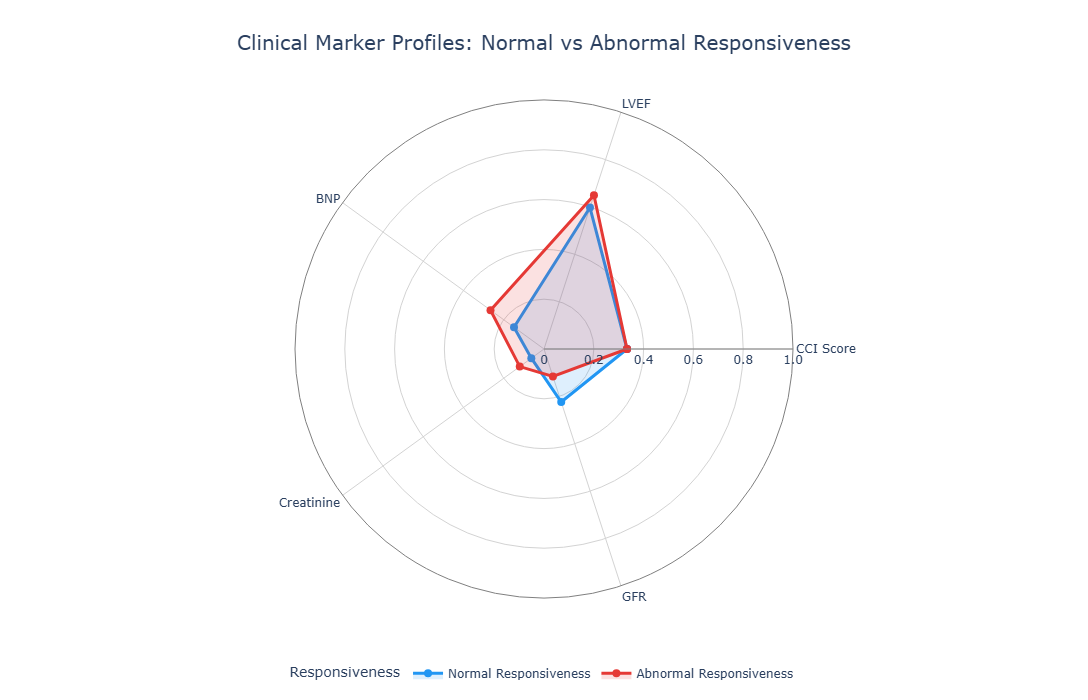

In [67]:
# ------------------------------------------------------------
# STEP 2: Create Normal / Abnormal responsiveness
# ------------------------------------------------------------

df["Response_Status"] = df["consciousness"].apply(
    lambda x: "Normal"
    if str(x).strip().lower() == "clear"
    else "Abnormal"
)

print("Responsiveness Distribution:")
print(df["Response_Status"].value_counts())


# ------------------------------------------------------------
# STEP 3: Convert clinical markers to numeric
# ------------------------------------------------------------

markers = [
    "cci_score",
    "lvef",
    "brain_natriuretic_peptide",
    "creatinine_enzymatic_method",
    "glomerular_filtration_rate"
]

for col in markers:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# STEP 4: Check missing values
# ------------------------------------------------------------

print("\nMissing Values:")
print(df[markers].isnull().sum())


# ------------------------------------------------------------
# STEP 5: Normalize clinical markers
# Min-Max Normalization: 0 to 1
# ------------------------------------------------------------

normalized_df = df.copy()

for col in markers:

    min_val = df[col].min()
    max_val = df[col].max()

    if pd.notna(min_val) and pd.notna(max_val):

        if max_val != min_val:

            normalized_df[col] = (
                (df[col] - min_val)
                /
                (max_val - min_val)
            )

        else:
            normalized_df[col] = 0


# ------------------------------------------------------------
# STEP 6: Calculate median marker values
# by responsiveness status
# ------------------------------------------------------------

radar_data = (
    normalized_df
    .groupby("Response_Status")[markers]
    .median()
)

print("\nNormalized Median Clinical Markers:")

display(
    radar_data.round(3)
)


# ------------------------------------------------------------
# STEP 7: Give markers readable names
# ------------------------------------------------------------

labels = [
    "CCI Score",
    "LVEF",
    "BNP",
    "Creatinine",
    "GFR"
]


# ------------------------------------------------------------
# STEP 8: Extract Normal responsiveness values
# ------------------------------------------------------------

normal_values = (
    radar_data
    .loc["Normal", markers]
    .tolist()
)


# ------------------------------------------------------------
# STEP 9: Extract Abnormal responsiveness values
# ------------------------------------------------------------

abnormal_values = (
    radar_data
    .loc["Abnormal", markers]
    .tolist()
)


# ------------------------------------------------------------
# STEP 10: Close the radar chart
# ------------------------------------------------------------

radar_labels = labels + [labels[0]]

normal_values = (
    normal_values
    + [normal_values[0]]
)

abnormal_values = (
    abnormal_values
    + [abnormal_values[0]]
)


# ------------------------------------------------------------
# STEP 11: Create interactive radar chart
# ------------------------------------------------------------

fig = go.Figure()


# ------------------------------------------------------------
# Normal Responsiveness
# ------------------------------------------------------------

fig.add_trace(

    go.Scatterpolar(

        r=normal_values,

        theta=radar_labels,

        fill="toself",

        name="Normal Responsiveness",

        line=dict(
            color="#2196F3",
            width=3
        ),

        marker=dict(
            color="#2196F3",
            size=8
        ),

        fillcolor="rgba(33, 150, 243, 0.15)",

        hovertemplate=(
            "<b>Normal Responsiveness</b><br>"
            "Marker: %{theta}<br>"
            "Normalized Median: %{r:.3f}"
            "<extra></extra>"
        )
    )
)


# ------------------------------------------------------------
# Abnormal Responsiveness
# ------------------------------------------------------------

fig.add_trace(

    go.Scatterpolar(

        r=abnormal_values,

        theta=radar_labels,

        fill="toself",

        name="Abnormal Responsiveness",

        line=dict(
            color="#E53935",
            width=3
        ),

        marker=dict(
            color="#E53935",
            size=8
        ),

        fillcolor="rgba(229, 57, 53, 0.15)",

        hovertemplate=(
            "<b>Abnormal Responsiveness</b><br>"
            "Marker: %{theta}<br>"
            "Normalized Median: %{r:.3f}"
            "<extra></extra>"
        )
    )
)


# ------------------------------------------------------------
# STEP 12: Format radar chart
# ------------------------------------------------------------

fig.update_layout(

    title=dict(

        text=(
            "Clinical Marker Profiles: "
            "Normal vs Abnormal Responsiveness"
        ),

        x=0.5,

        xanchor="center",

        font=dict(
            size=20
        )
    ),

    polar=dict(

        bgcolor="white",

        radialaxis=dict(

            visible=True,

            range=[0, 1],

            tickvals=[
                0,
                0.2,
                0.4,
                0.6,
                0.8,
                1.0
            ],

            ticktext=[
                "0",
                "0.2",
                "0.4",
                "0.6",
                "0.8",
                "1.0"
            ],

            gridcolor="lightgray",

            linecolor="gray"
        ),

        angularaxis=dict(

            gridcolor="lightgray",

            linecolor="gray"
        )
    ),

    legend=dict(

        title="Responsiveness",

        orientation="h",

        yanchor="bottom",

        y=-0.18,

        xanchor="center",

        x=0.5
    ),

    width=800,

    height=700,

    template="plotly_white",

    margin=dict(
        l=80,
        r=80,
        t=100,
        b=100
    )
)


# ------------------------------------------------------------
# STEP 13: Display interactive radar chart
# ------------------------------------------------------------

fig.show()



<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight :</b> One result we already know from your responsiveness data is that the groups are highly imbalanced: approximately 1,974 patients were classified as Normal/Clear and only 34 as Abnormal responsiveness. Therefore, differences in the abnormal group should be interpreted cautiously.
For the demographic component, your earlier analysis showed that abnormal responsiveness occurred most often by count in the 79–89 age group (15 patients), while males had 18 abnormal cases and females 16. However, counts alone should not be interpreted as prevalence because demographic group sizes differ.</p>

<p style="font-family: Cambria; font-size: 20px;"><b>Question 4 : How do average eGFR levels differ across age groups and genders, and what demographic patterns emerge in renal function? 
</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>Comparing eGFR levels across age groups and genders helps us understand how kidney function measurements differ among patients. A line chart makes it easier to identify changes in average eGFR levels across age categories and compare patterns between males and females.


In [68]:

# ------------------------------------------------------------------
# Step 1 : Merge labs, prescriptionsy and demography
# ------------------------------------------------------------------
# Define CSV filenames
FILES = {
    "labs": "Team7_CodeAvengers_Category1_DataCleaning_labs.csv",
    "prescriptions": "Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv",
    "demography": "Team7_CodeAvengers_Category1_DataCleaning_demography.csv",
}

# Read the cleaned datasets
labs = pd.read_csv(BASE_URL + FILES["labs"])
prescriptions = pd.read_csv(BASE_URL + FILES["prescriptions"])
demography = pd.read_csv(BASE_URL + FILES["demography"])

# Verify successful loading
print("Labs:", labs.shape)
print("Prescriptions:", prescriptions.shape)
print("Demography:", demography.shape)

Labs: (2008, 107)
Prescriptions: (15362, 2)
Demography: (2008, 7)


In [69]:
# Validate patient-level uniqueness before merging.
for name, df in {"labs": labs, "demography": demography}.items():
    print("\t")
    print(
        f"{name:12s} rows={len(df):,} | "
        f"unique patients={df['inpatient_number'].nunique():,} | "
        f"duplicate patient IDs={df['inpatient_number'].duplicated().sum():,}"
    )
print("\t")
print(
    f"prescriptions rows={len(prescriptions):,} | "
    f"unique patients={prescriptions['inpatient_number'].nunique():,} | "
    f"unique drug names={prescriptions['drug_name'].nunique():,}"
)

# Clean drug-name whitespace only; do not change clinical content.
rx = prescriptions.copy()
rx["drug_name"] = rx["drug_name"].astype(str).str.strip()

# Aggregate prescriptions BEFORE patient-level merge to avoid multiplying lab rows.
rx_summary = (
    rx.groupby("inpatient_number")
      .agg(
          prescription_rows=("drug_name", "size"),
          unique_medication_count=("drug_name", "nunique")
      )
      .reset_index()
)

patient = (
    labs
    .merge(demography, on="inpatient_number", how="left", validate="one_to_one")
    .merge(rx_summary, on="inpatient_number", how="left", validate="one_to_one")
)

patient[["prescription_rows", "unique_medication_count"]] = (
    patient[["prescription_rows", "unique_medication_count"]].fillna(0)
)

AGE_ORDER = ["21-29", "29-39", "39-49", "49-59", "59-69", "69-79", "79-89", "89-110"]
AGE_MIDPOINT = {
    "21-29": 25, "29-39": 34, "39-49": 44, "49-59": 54,
    "59-69": 64, "69-79": 74, "79-89": 84, "89-110": 99.5
}

patient["agecat"] = pd.Categorical(patient["agecat"], categories=AGE_ORDER, ordered=True)
patient["age_midpoint"] = patient["agecat"].astype(str).map(AGE_MIDPOINT)

print("\n Final patient-level analytical dataset:", patient.shape)
print("\n Unique patients:", patient["inpatient_number"].nunique())

	
labs         rows=2,008 | unique patients=2,008 | duplicate patient IDs=0
	
demography   rows=2,008 | unique patients=2,008 | duplicate patient IDs=0
	
prescriptions rows=15,362 | unique patients=2,007 | unique drug names=25

 Final patient-level analytical dataset: (2008, 116)

 Unique patients: 2008


In [70]:
# Helper functions reused throughout the notebook.

def p_text(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "< 0.001"
    return f"= {p:.3f}"

def safe_spearman(df, x, y):
    tmp = df[[x, y]].dropna()
    if len(tmp) < 3:
        return np.nan, np.nan, len(tmp)
    rho, p = spearmanr(tmp[x], tmp[y])
    return rho, p, len(tmp)

def med_usage_by_group(group_col, drugs):
    unique_rx = (
        rx.drop_duplicates(["inpatient_number", "drug_name"])
          .merge(patient[["inpatient_number", group_col]], on="inpatient_number", how="left")
    )
    numerator = (
        unique_rx[unique_rx["drug_name"].isin(drugs)]
        .groupby([group_col, "drug_name"], observed=True)["inpatient_number"]
        .nunique()
        .unstack(fill_value=0)
    )
    denominator = patient.groupby(group_col, observed=True)["inpatient_number"].nunique()
    return numerator.div(denominator, axis=0) * 100

def standardized_mean_difference(df, group_col, value_col):
    a = df.loc[df[group_col], value_col].dropna()
    b = df.loc[~df[group_col], value_col].dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled = np.sqrt(
        ((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1))
        / (len(a)+len(b)-2)
    )
    return (a.mean()-b.mean())/pooled if pooled else np.nan

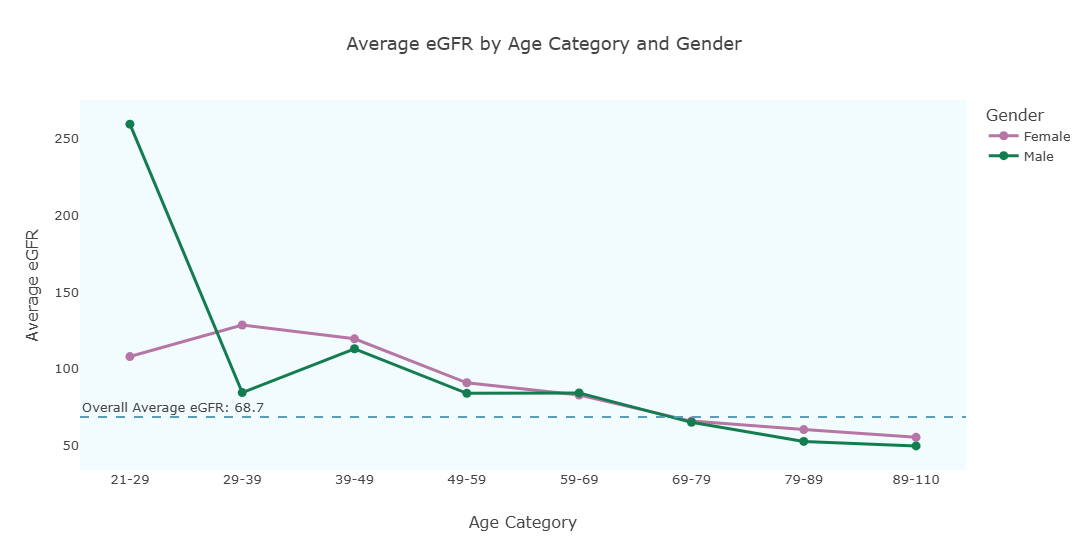

,Age Category,Gender,Average eGFR,Records
0,21-29,Female,108.06,3
1,21-29,Male,259.51,1
2,29-39,Female,128.59,5
3,29-39,Male,84.58,7
4,39-49,Female,119.61,17
5,39-49,Male,113.15,37
6,49-59,Female,90.96,49
7,49-59,Male,84.11,55
8,59-69,Female,82.98,182
9,59-69,Male,84.37,172


In [71]:
# Prepare data
tmp = patient[
    ["agecat", "gender", "glomerular_filtration_rate"]
].dropna()

# Calculate average eGFR by age category and gender
egfr_by_group = (
    tmp.groupby(["agecat", "gender"], observed=True)["glomerular_filtration_rate"]
       .agg(["mean", "count"])
       .reset_index()
)

# Create line chart
fig = px.line(
    egfr_by_group,
    x="agecat",
    y="mean",
    color="gender",
    markers=True,
    title="Average eGFR by Age Category and Gender",
    labels={
        "agecat": "Age Category",
        "mean": "Average eGFR",
        "gender": "Gender"
    },
    color_discrete_sequence=["#B576A5", "#147D50"],
    hover_data=["count"]
)

# Customize lines and markers
fig.update_traces(
    line=dict(width=3),
    marker=dict(size=9)
)

# Add overall average reference line
overall_avg = tmp["glomerular_filtration_rate"].mean()

fig.add_hline(
    y=overall_avg,
    line_dash="dash",
    line_color="#5B9DB8",
    annotation_text=f"Overall Average eGFR: {overall_avg:.1f}",
    annotation_position="top left"
)

# Customize chart appearance
fig.update_layout(
    height=550,
    plot_bgcolor="#F2FBFD",
    paper_bgcolor="white",
    title_x=0.5,
    xaxis_title="Age Category",
    yaxis_title="Average eGFR",
    legend_title="Gender",
    font=dict(size=13),
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False)
)

fig.show()

# Display summary table
display(
    egfr_by_group
    .rename(columns={
        "agecat": "Age Category",
        "gender": "Gender",
        "mean": "Average eGFR",
        "count": "Records"
    })
    .round(2)
)

<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight :</b> Average eGFR levels generally decrease as age increases, suggesting that kidney function tends to be lower in older patients. Males and females show a similar pattern after age 39, with eGFR levels falling below the overall average in the older age groups. The unusually high value for males aged 21–29 may be due to a small number of records and should be checked before drawing conclusions.

<p style="font-family: Cambria; font-size: 20px;"><b>Question 5 : How does the utilization of the most commonly prescribed medications differ across age groups, and what age-related medication-use patterns can be identified? 
</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>A heat map can compare several medications and age categories simultaneously. Percent prevalence is used instead of raw counts so age groups with different sizes can be compared fairly.    
    

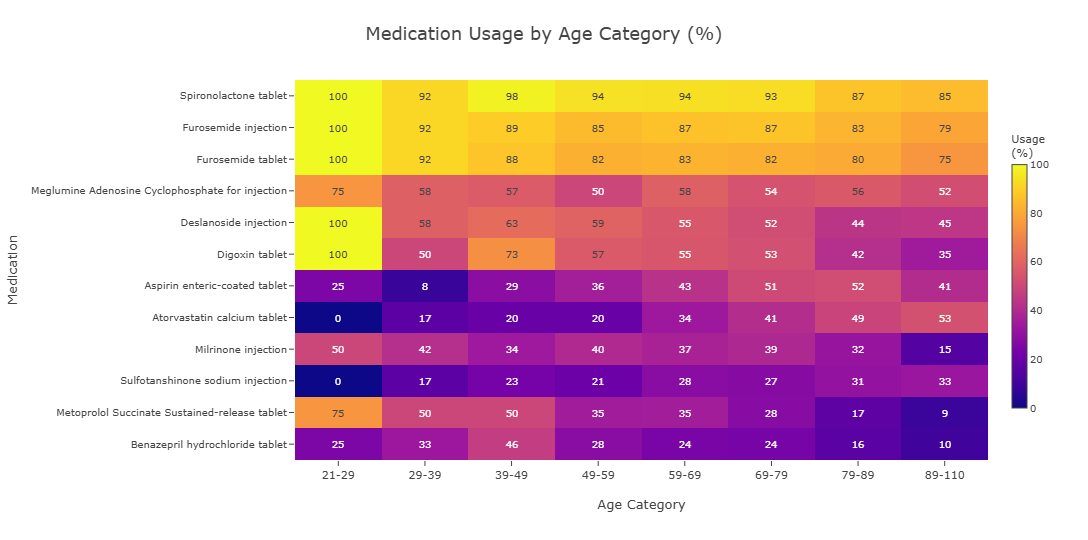

drug_name,Spironolactone tablet,Furosemide injection,Furosemide tablet,Meglumine Adenosine Cyclophosphate for injection,Deslanoside injection,Digoxin tablet,Aspirin enteric-coated tablet,Atorvastatin calcium tablet,Milrinone injection,Sulfotanshinone sodium injection,Metoprolol Succinate Sustained-release tablet,Benazepril hydrochloride tablet
agecat,,,,,,,,,,,,
21-29,100.0,100.0,100.0,75.0,100.0,100.0,25.0,0.0,50.0,0.0,75.0,25.0
29-39,91.7,91.7,91.7,58.3,58.3,50.0,8.3,16.7,41.7,16.7,50.0,33.3
39-49,98.2,89.3,87.5,57.1,62.5,73.2,28.6,19.6,33.9,23.2,50.0,46.4
49-59,94.3,84.9,82.1,50.0,59.4,56.6,35.8,19.8,39.6,20.8,34.9,28.3
59-69,93.8,86.7,83.2,58.4,55.4,55.2,42.7,33.7,37.2,28.3,35.3,24.2
69-79,93.3,87.4,82.2,54.1,52.3,53.1,51.2,41.1,39.3,27.4,27.7,23.6
79-89,87.5,83.4,80.5,56.3,43.8,41.6,52.3,48.9,31.9,31.0,17.3,16.3
89-110,85.1,79.2,75.2,52.5,44.6,34.7,40.6,53.5,14.9,32.7,8.9,9.9


In [73]:
# ============================================================
# DA8: MEDICATION UTILIZATION BY AGE CATEGORY
# Clean Heatmap with Improved Labels and Display
# ============================================================

# ---------------------------------------------------------
# Step 1: Keep patient age-category information
# ---------------------------------------------------------

patient_data = (
    patient[
        ["inpatient_number", "agecat"]
    ]
    .dropna()
    .drop_duplicates()
)


# ---------------------------------------------------------
# Step 2: Keep prescription information
# ---------------------------------------------------------

rx_data = (
    rx[
        ["inpatient_number", "drug_name"]
    ]
    .dropna()
    .drop_duplicates()
)


# ---------------------------------------------------------
# Step 3: Merge age category with medication information
# ---------------------------------------------------------

med_data = patient_data.merge(
    rx_data,
    on="inpatient_number",
    how="inner"
)


# ---------------------------------------------------------
# Step 4: Identify 12 most commonly used medications
# ---------------------------------------------------------

drug_prev = (
    med_data
    .groupby("drug_name")["inpatient_number"]
    .nunique()
    .sort_values(ascending=False)
)

top_drugs = (
    drug_prev
    .head(12)
    .index
    .tolist()
)


# ---------------------------------------------------------
# Step 5: Count patients in each age category
# ---------------------------------------------------------

age_counts = (
    patient_data
    .groupby(
        "agecat",
        observed=True
    )["inpatient_number"]
    .nunique()
)


# ---------------------------------------------------------
# Step 6: Calculate medication use by age category
# ---------------------------------------------------------

med_counts = (
    med_data[
        med_data["drug_name"].isin(top_drugs)
    ]
    .groupby(
        [
            "agecat",
            "drug_name"
        ],
        observed=True
    )["inpatient_number"]
    .nunique()
    .unstack(fill_value=0)
)


# ---------------------------------------------------------
# Step 7: Convert counts to prevalence percentage
# ---------------------------------------------------------

age_med = (
    med_counts
    .div(
        age_counts,
        axis=0
    )
    .mul(100)
)


# Keep predefined age-category order
age_med = age_med.reindex(
    AGE_ORDER
)


# Keep medication order based on overall prevalence
available_drugs = [
    drug
    for drug in top_drugs
    if drug in age_med.columns
]

age_med = age_med[
    available_drugs
]


# ---------------------------------------------------------
# Step 8: Create Heatmap
# ---------------------------------------------------------

fig = px.imshow(

    age_med.T,

    aspect="auto",

    text_auto=".0f",

    color_continuous_scale="Plasma",

    zmin=0,
    zmax=100,

    title=(
        "Medication Usage by Age Category (%)"
    ),

    labels={
        "x": "Age Category",
        "y": "Medication",
        "color": "Usage (%)"
    }
)


# ---------------------------------------------------------
# Step 9: Improve Heatmap Appearance
# ---------------------------------------------------------

fig.update_layout(

    # Slightly smaller/cleaner overall display
    width=1050,
    height=540,

    # Center title
    title=dict(
        x=0.5,
        xanchor="center",
        font=dict(
            size=18
        )
    ),

    # -----------------------------------------------------
    # X AXIS
    # -----------------------------------------------------

    xaxis=dict(

        title=dict(
            text="Age Category",
            font=dict(
                size=13
            )
        ),

        tickfont=dict(
            size=11
        ),

        tickangle=0,

        automargin=True
    ),


    # -----------------------------------------------------
    # Y AXIS
    # -----------------------------------------------------

    yaxis=dict(

        title=dict(
            text="Medication",
            font=dict(
                size=13
            ),
            standoff=10
        ),

        # Smaller medication labels
        tickfont=dict(
            size=10
        ),

        automargin=True
    ),


    # -----------------------------------------------------
    # COLOR BAR
    # -----------------------------------------------------

    coloraxis_colorbar=dict(

        title=dict(
            text="Usage<br>(%)",
            font=dict(
                size=11
            )
        ),

        thickness=15,

        len=0.78,

        x=1.02,

        tickfont=dict(
            size=10
        )
    ),


    # -----------------------------------------------------
    # IMPORTANT: MORE LEFT SPACE FOR MEDICATION NAMES
    # -----------------------------------------------------

    margin=dict(
        l=230,
        r=100,
        t=80,
        b=80
    ),

    paper_bgcolor="white",

    plot_bgcolor="white"
)


# ---------------------------------------------------------
# Step 10: Improve Cell Text
# ---------------------------------------------------------

fig.update_traces(

    textfont=dict(
        size=10
    ),

    hovertemplate=(
        "<b>Medication:</b> %{y}"
        "<br><b>Age Category:</b> %{x}"
        "<br><b>Medication Usage:</b> %{z:.1f}%"
        "<extra></extra>"
    )
)


# ---------------------------------------------------------
# Step 11: Display Heatmap
# ---------------------------------------------------------

fig.show()


# ---------------------------------------------------------
# Step 12: Display Calculated Prevalence Values
# ---------------------------------------------------------

display(
    age_med.round(1)
)

<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight :</b> Medication utilization differs across age groups, with certain commonly prescribed drugs showing greater usage in specific age categories. These patterns may reflect age-related differences in chronic disease burden and treatment requirements and can help identify patient groups where medication use may require closer clinical review.

<p style="font-family: Cambria; font-size: 20px;"><b>Question 6 : Does cardiac functional impairment, measured by NYHA class, correlate with elevated BNP and Troponin levels? (Association Between NYHA Severity Class and Cardiac Biomarkers) 
</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>Connecting functional classification (NYHA) to blood markers (BNP and Troponin) validates clinical severity with quantitative lab metrics.    
    

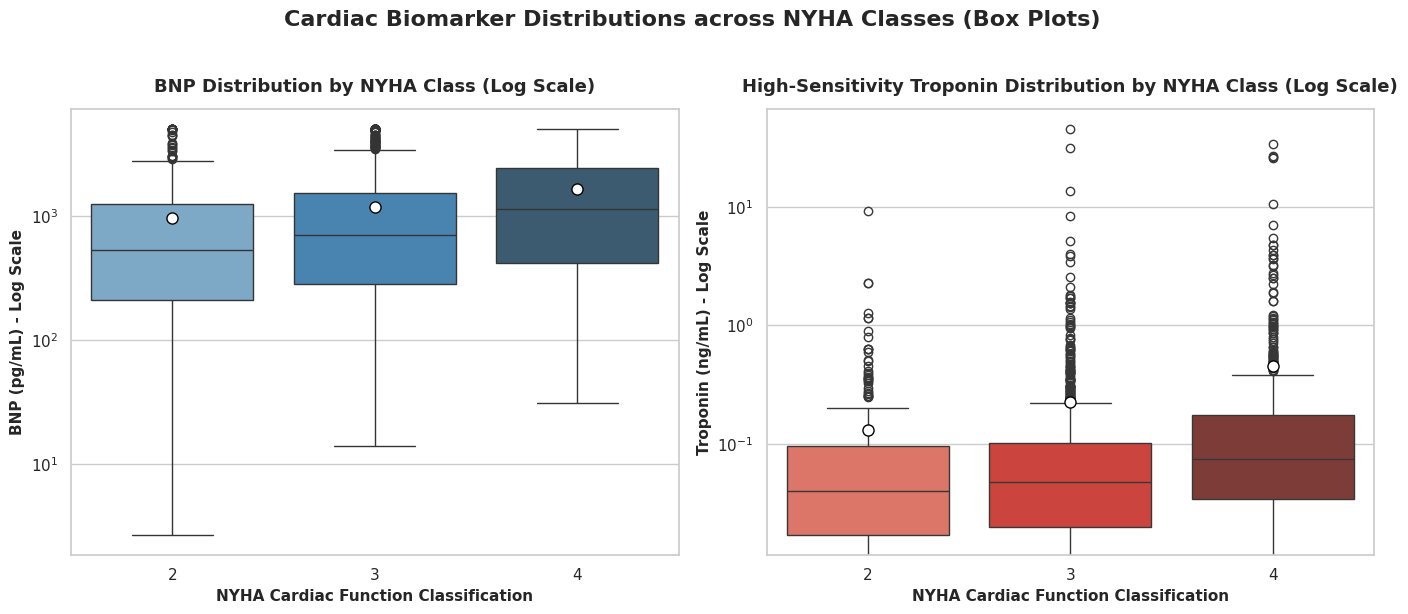

In [74]:
# ============================================================
# NYHA CLASS vs CARDIAC BIOMARKERS
# ============================================================

import logging
import warnings
import matplotlib as mpl

# Suppress standard warnings
warnings.filterwarnings("ignore")

# Suppress Matplotlib findfont messages
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# Use a standard Matplotlib font
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["mathtext.fontset"] = "dejavusans"
mpl.rcParams["axes.unicode_minus"] = False

# ------------------------------------------------------------
# 1. Load datasets
# ------------------------------------------------------------

cardiac = pd.read_csv(
    BASE_URL + "Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv"
)

labs = pd.read_csv(
    BASE_URL + "Team7_CodeAvengers_Category1_DataCleaning_labs.csv"
)

# ------------------------------------------------------------
# 2. Merge datasets
# ------------------------------------------------------------

df = cardiac.merge(
    labs[
        [
            "inpatient_number",
            "high_sensitivity_troponin",
            "brain_natriuretic_peptide"
        ]
    ],
    on="inpatient_number"
)

# ------------------------------------------------------------
# 3. Filter valid NYHA classes
# ------------------------------------------------------------

df = df[
    df["nyha_cardiac_function_classification"].isin(
        [2, 3, 4, "2", "3", "4"]
    )
].copy()

df["nyha_cardiac_function_classification"] = (
    df["nyha_cardiac_function_classification"].astype(str)
)

order = ["2", "3", "4"]

# ------------------------------------------------------------
# 4. Create plots
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# BNP Box Plot
sns.boxplot(
    data=df,
    x="nyha_cardiac_function_classification",
    y="brain_natriuretic_peptide",
    hue="nyha_cardiac_function_classification",
    order=order,
    hue_order=order,
    ax=axes[0],
    palette="Blues_d",
    legend=False,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 8
    }
)

axes[0].set_yscale("log")

axes[0].set_title(
    "BNP Distribution by NYHA Class (Log Scale)",
    fontsize=13,
    fontweight="bold",
    pad=12
)

axes[0].set_xlabel(
    "NYHA Cardiac Function Classification",
    fontsize=11,
    fontweight="bold"
)

axes[0].set_ylabel(
    "BNP (pg/mL) - Log Scale",
    fontsize=11,
    fontweight="bold"
)

# ------------------------------------------------------------
# High-Sensitivity Troponin Box Plot
# ------------------------------------------------------------

sns.boxplot(
    data=df,
    x="nyha_cardiac_function_classification",
    y="high_sensitivity_troponin",
    hue="nyha_cardiac_function_classification",
    order=order,
    hue_order=order,
    ax=axes[1],
    palette="Reds_d",
    legend=False,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 8
    }
)

axes[1].set_yscale("log")

axes[1].set_title(
    "High-Sensitivity Troponin Distribution by NYHA Class (Log Scale)",
    fontsize=13,
    fontweight="bold",
    pad=12
)

axes[1].set_xlabel(
    "NYHA Cardiac Function Classification",
    fontsize=11,
    fontweight="bold"
)

axes[1].set_ylabel(
    "Troponin (ng/mL) - Log Scale",
    fontsize=11,
    fontweight="bold"
)

# ------------------------------------------------------------
# 5. Overall formatting
# ------------------------------------------------------------

fig.suptitle(
    "Cardiac Biomarker Distributions across NYHA Classes (Box Plots)",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

# ------------------------------------------------------------
# 6. Save and display
# ------------------------------------------------------------

plt.savefig(
    "nyha_biomarkers_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight :</b>113% BNP Surge (Wall Stress): Median BNP jumps from 529.8 to 1,130.3 pg/mL as severity increases from Class 2 to 4, showing double the fluid overload.   

85% Troponin Rise (Heart Damage): Median Troponin climbs from 0.040 to 0.074 ng/mL, proving ongoing myocardial tissue damage across all classes.   

High Outlier Spike (Decompensation): Means (white dots) sit much higher than medians (e.g., Class 4 BNP mean is 1,638.6 pg/mL), pinpointing acute high-risk patient spikes.   

<p style="font-family: Cambria; font-size: 20px;"><b>Question 7 : How drastically do serum Creatinine, Urea, and eGFR change in patients diagnosed with Acute Renal Failure?
(Renal Function Impairment in Acute Renal Failure Cases)
</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>Evaluates kidney biomarker degradation when acute kidney injury/failure is recorded in patient medical history.


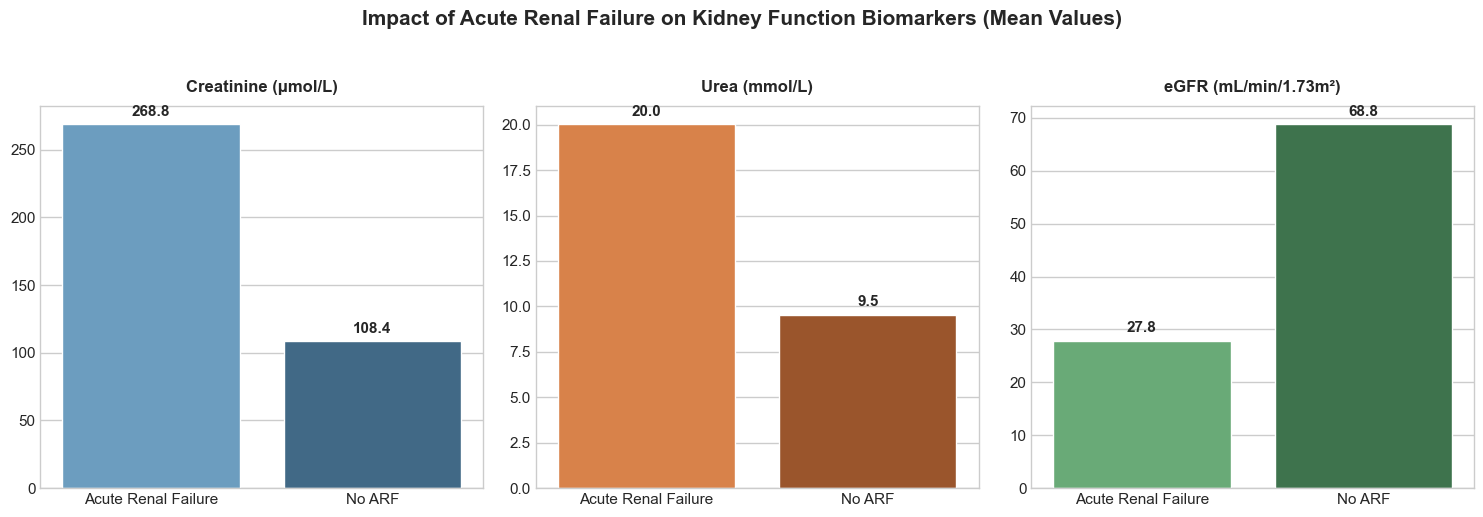

In [75]:
# 1. Load and merge datasets

history = pd.read_csv(
   BASE_URL + "Team7_CodeAvengers_Category1_DataCleaning_patienthistory_cleaned.csv"
)

labs = pd.read_csv(
   BASE_URL + "Team7_CodeAvengers_Category1_DataCleaning_labs.csv"
)

merged_q4 = history.merge(
    labs[
        [
            'inpatient_number',
            'creatinine_enzymatic_method',
            'urea',
            'glomerular_filtration_rate'
        ]
    ],
    on='inpatient_number'
)

# 2. Map categorical labels
merged_q4['acute_renal_failure_label'] = merged_q4['acute_renal_failure'].map({0: 'No ARF', 1: 'Acute Renal Failure'})

# 3. Create 3-panel bar charts
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ('creatinine_enzymatic_method', 'Creatinine (μmol/L)', 'Blues_d'),
    ('urea', 'Urea (mmol/L)', 'Oranges_d'),
    ('glomerular_filtration_rate', 'eGFR (mL/min/1.73m²)', 'Greens_d')
]

for idx, (col, title, palette) in enumerate(metrics):
    df_plot = merged_q4.groupby('acute_renal_failure_label')[col].mean().reset_index()
    sns.barplot(data=df_plot, x='acute_renal_failure_label', y=col, ax=axes[idx], palette=palette)
    axes[idx].set_title(title, fontsize=12, fontweight='bold', pad=10)
    axes[idx].set_xlabel('', fontsize=10)
    axes[idx].set_ylabel('', fontsize=10)
    
    # Add numerical value labels on top of bars
    for p in axes[idx].patches:
        h = p.get_height()
        if not pd.isna(h):
            axes[idx].annotate(f'{h:.1f}', (p.get_x() + p.get_width() / 2., h),
                               ha='center', va='bottom', fontsize=11, fontweight='bold',
                               xytext=(0, 4), textcoords='offset points')

fig.suptitle('Impact of Acute Renal Failure on Kidney Function Biomarkers (Mean Values)', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('arf_kidney_biomarkers_barchart.png', dpi=300, bbox_inches='tight')
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight :</b> Creatinine (+148% increase): Jumps from an average of 108.4 μmol/L (No ARF) to 268.8 μmol/L (ARF).

Urea (+110% increase): More than doubles from 9.5 mmol/L (No ARF) to 20.0 mmol/L (ARF).

eGFR (-60% drop): Drops severely from 68.8 mL/min/1.73m² (No ARF) down to 27.8 mL/min/1.73m² (ARF), indicating severe loss of kidney filtration capability.

<p style="font-family: Cambria; font-size: 20px;"><b>Question 8 : What are the most common comorbidities?

</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>This identifies the major pre-existing conditions in the heart-failure population.

In [78]:
df = pd.read_csv(
   BASE_URL + "Team7_CodeAvengers_Category1_DataCleaning_patienthistory_cleaned.csv"
)
df.shape
# Select comorbidity columns
comorbidity_cols = [
    'cerebrovascular_disease',
    'dementia',
    'chronic_obstructive_pulmonary_disease',
    'connective_tissue_disease',
    'peptic_ulcer_disease',
    'diabetes',
    'moderate_to_severe_chronic_kidney_disease',
    'hemiplegia',
    'leukemia',
    'malignant_lymphoma',
    'solid_tumor',
    'liver_disease',
    'aids',
    'acute_renal_failure'
]

# Calculate prevalence
prevalence = (
    df[comorbidity_cols]
    .mean()
    .mul(100)
    .reset_index()
)

prevalence.columns = ['Comorbidity', 'Percentage']

prevalence

,Comorbidity,Percentage
0,cerebrovascular_disease,7.470120
1,dementia,5.727092
2,chronic_obstructive_pulmonary_disease,11.603586
3,connective_tissue_disease,0.199203
4,peptic_ulcer_disease,2.243270
5,diabetes,23.207171
6,moderate_to_severe_chronic_kidney_disease,23.629113
7,hemiplegia,0.597610
8,leukemia,0.000000
9,malignant_lymphoma,0.049801


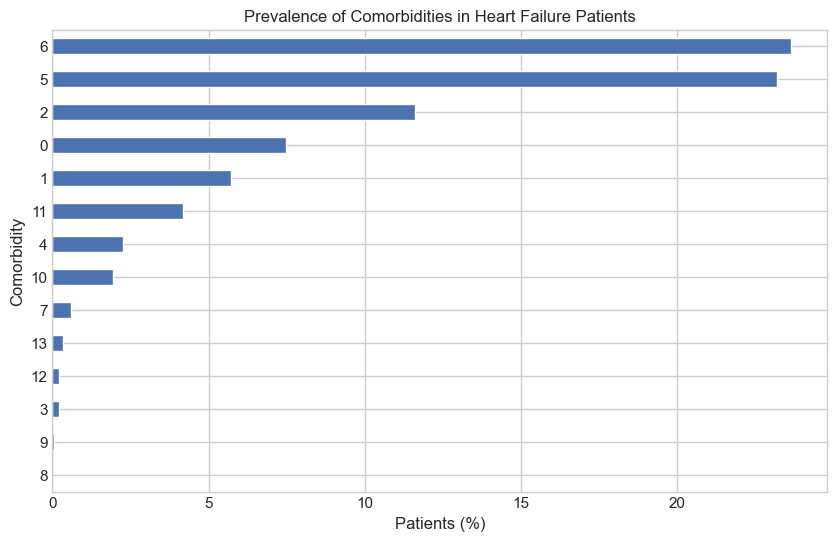

In [79]:
prevalence['Percentage'].sort_values().plot(
    kind='barh',
    figsize=(10, 6)
)

plt.xlabel('Patients (%)')
plt.ylabel('Comorbidity')
plt.title('Prevalence of Comorbidities in Heart Failure Patients')
plt.show()


<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight :</b> Moderate-to-severe chronic kidney disease and diabetes are the two most common comorbidities among the heart-failure patients in this dataset.COPD is the next most prevalent condition, while the remaining comorbidities occur less frequently. This suggests that kidney disease and diabetes are important conditions to consider when further analyzing the clinical profiles of these patients.

<p style="font-family: Cambria; font-size: 20px;"><b> Question 9 :<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight :</b> The majority of heart-failure patients did **not** have Type II respiratory failure.Out of **2,008 patients**, **1,894 (94.3%)** were classified as non-Type II respiratory failure. Only **114 patients (5.7%)** were classified as having Type II respiratory failure. This indicates that **Type II respiratory failure is relatively uncommon** in this study population.</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>
Comparing IMV and NIMV utilization across NYHA functional classes helps characterize respiratory-support patterns at different levels of cardiac functional impairment. A Waffle Small Multiples chart provides an intuitive proportional comparison, with each NYHA class represented separately while maintaining the same visual scale.</p>

Respiratory Support Summary:


,NYHA Class,Respiratory Support,Patient Count,Total,Percentage
0,NYHA Class 2,NIMV,1,1,100.000000
1,NYHA Class 3,IMV,4,8,50.000000
2,NYHA Class 3,NIMV,4,8,50.000000
3,NYHA Class 4,IMV,21,33,63.636364
4,NYHA Class 4,NIMV,12,33,36.363636


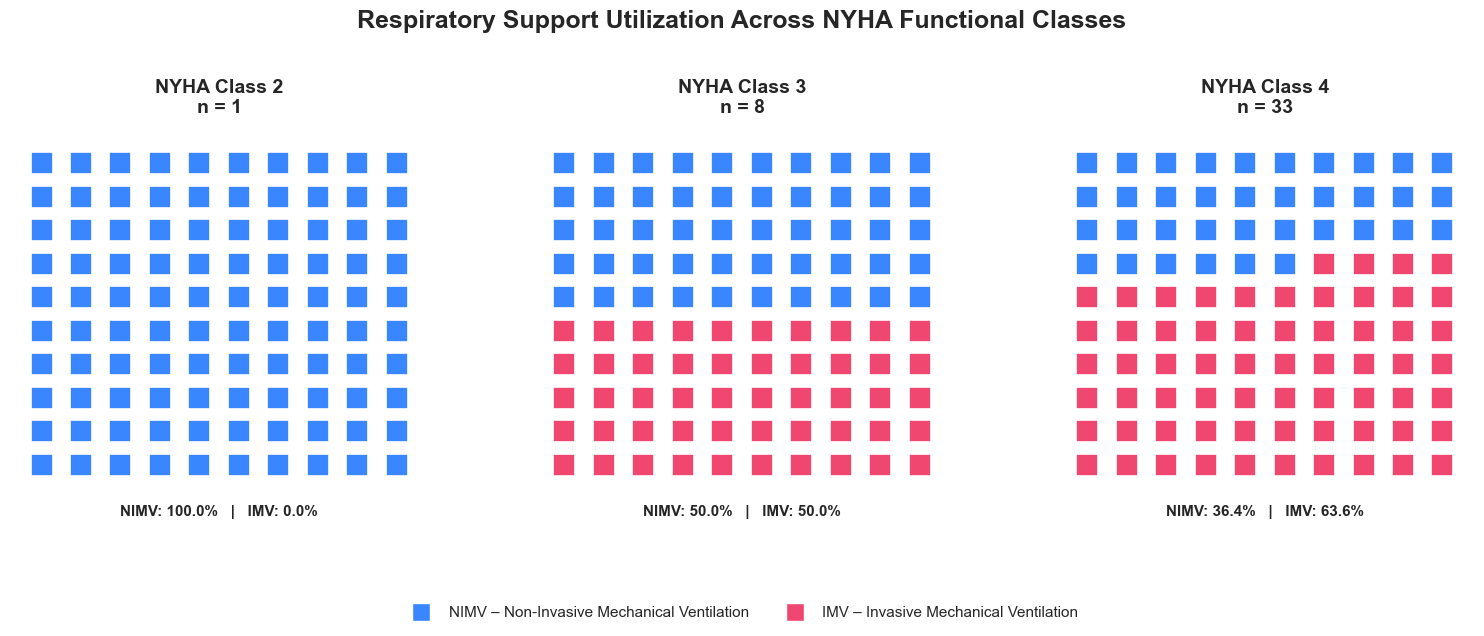

In [81]:
# ============================================================
# QUESTION 9
# RESPIRATORY SUPPORT BY NYHA FUNCTIONAL CLASS
# WAFFLE SMALL MULTIPLES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")


# ============================================================
# 1. LOAD DATASETS
# ============================================================

cardiac = pd.read_csv(
    BASE_URL +
    "Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv"
)

hospital = pd.read_csv(
    BASE_URL +
    "Team7_CodeAvengers_Category1_DataCleaning_hospitalization_discharge.csv"
)


# ============================================================
# 2. SELECT REQUIRED VARIABLES
# ============================================================

cardiac_selected = cardiac[
    [
        "inpatient_number",
        "nyha_cardiac_function_classification"
    ]
].copy()

hospital_selected = hospital[
    [
        "inpatient_number",
        "respiratory_support"
    ]
].copy()


# ============================================================
# 3. MERGE DATASETS
# ============================================================

df = cardiac_selected.merge(
    hospital_selected,
    on="inpatient_number",
    how="inner"
)


# ============================================================
# 4. REMOVE MISSING VALUES
# ============================================================

df = df.dropna(
    subset=[
        "nyha_cardiac_function_classification",
        "respiratory_support"
    ]
).copy()


# ============================================================
# 5. CLEAN NYHA CLASS
# ============================================================

df["NYHA Class"] = (
    df["nyha_cardiac_function_classification"]
    .astype(str)
    .str.strip()
    .str.replace(".0", "", regex=False)
)

df = df[
    df["NYHA Class"].isin(
        ["1", "2", "3", "4"]
    )
].copy()

df["NYHA Class"] = (
    "NYHA Class " + df["NYHA Class"]
)


# ============================================================
# 6. CLEAN RESPIRATORY SUPPORT
# ============================================================

df["Respiratory Support"] = (
    df["respiratory_support"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df = df[
    df["Respiratory Support"].isin(
        ["NIMV", "IMV"]
    )
].copy()


# ============================================================
# 7. REMOVE DUPLICATE PATIENTS
# ============================================================

df = df.drop_duplicates(
    subset=["inpatient_number"]
).copy()


# ============================================================
# 8. CREATE SUMMARY TABLE
# ============================================================

summary = (
    df.groupby(
        [
            "NYHA Class",
            "Respiratory Support"
        ]
    )
    .size()
    .reset_index(name="Patient Count")
)


# Calculate total patients within each NYHA class
summary["Total"] = (
    summary.groupby("NYHA Class")["Patient Count"]
    .transform("sum")
)


# Calculate percentage
summary["Percentage"] = (
    summary["Patient Count"] /
    summary["Total"] *
    100
)


print("Respiratory Support Summary:")
display(summary)


# ============================================================
# 9. DEFINE COLORS
# ============================================================

support_colors = {
    "NIMV": "#3A86FF",
    "IMV": "#EF476F"
}


# ============================================================
# 10. CREATE WAFFLE FUNCTION
# ============================================================

def create_waffle(ax, class_data, nyha_class):

    # Get counts
    values = {}

    for support in ["NIMV", "IMV"]:

        temp = class_data[
            class_data["Respiratory Support"] == support
        ]

        if len(temp) > 0:
            values[support] = temp["Patient Count"].iloc[0]
        else:
            values[support] = 0


    total = sum(values.values())

    if total == 0:
        ax.axis("off")
        return


    # Calculate percentages
    nimv_pct = values["NIMV"] / total * 100
    imv_pct = values["IMV"] / total * 100


    # Convert percentage into 100 waffle squares
    nimv_squares = int(round(nimv_pct))

    imv_squares = 100 - nimv_squares


    waffle_values = (
        ["NIMV"] * nimv_squares +
        ["IMV"] * imv_squares
    )


    # 10 x 10 waffle grid
    rows = 10
    cols = 10


    for i in range(100):

        row = 9 - (i // cols)
        col = i % cols

        category = waffle_values[i]

        ax.scatter(
            col,
            row,
            s=260,
            marker="s",
            color=support_colors[category],
            edgecolor="white",
            linewidth=1.2
        )


    # --------------------------------------------------------
    # PANEL TITLE
    # --------------------------------------------------------

    ax.set_title(
        f"{nyha_class}\n"
        f"n = {total}",
        fontsize=14,
        fontweight="bold",
        pad=12
    )


    # --------------------------------------------------------
    # PERCENTAGE LABELS
    # --------------------------------------------------------

    ax.text(
        4.5,
        -1.4,
        f"NIMV: {nimv_pct:.1f}%   |   IMV: {imv_pct:.1f}%",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )


    # --------------------------------------------------------
    # CLEAN AXES
    # --------------------------------------------------------

    ax.set_xlim(-0.8, 9.8)
    ax.set_ylim(-2, 10)

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)


# ============================================================
# 11. GET AVAILABLE NYHA CLASSES
# ============================================================

nyha_order = [
    "NYHA Class 1",
    "NYHA Class 2",
    "NYHA Class 3",
    "NYHA Class 4"
]

available_classes = [
    x for x in nyha_order
    if x in summary["NYHA Class"].unique()
]


# ============================================================
# 12. CREATE SMALL MULTIPLES
# ============================================================

n_classes = len(available_classes)

fig, axes = plt.subplots(
    1,
    n_classes,
    figsize=(5 * n_classes, 6)
)


# Make axes iterable when only one class exists
if n_classes == 1:
    axes = [axes]


# ============================================================
# 13. DRAW EACH WAFFLE PANEL
# ============================================================

for ax, nyha_class in zip(
    axes,
    available_classes
):

    class_data = summary[
        summary["NYHA Class"] == nyha_class
    ]

    create_waffle(
        ax,
        class_data,
        nyha_class
    )


# ============================================================
# 14. MAIN TITLE
# ============================================================

fig.suptitle(
    "Respiratory Support Utilization Across NYHA Functional Classes",
    fontsize=18,
    fontweight="bold",
    y=1.02
)


# ============================================================
# 15. LEGEND
# ============================================================

from matplotlib.lines import Line2D

legend_elements = [

    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        label="NIMV – Non-Invasive Mechanical Ventilation",
        markerfacecolor="#3A86FF",
        markersize=13
    ),

    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        label="IMV – Invasive Mechanical Ventilation",
        markerfacecolor="#EF476F",
        markersize=13
    )
]


fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, -0.02)
)


# ============================================================
# 16. FINAL FORMATTING
# ============================================================

plt.tight_layout()

plt.subplots_adjust(
    bottom=0.15,
    top=0.82,
    wspace=0.25
)


# ============================================================
# 17. SAVE CHART
# ============================================================

plt.savefig(
    "respiratory_support_waffle_small_multiples.png",
    dpi=300,
    bbox_inches="tight"
)


# ============================================================
# 18. DISPLAY CHART
# ============================================================

plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b> Actual Insight</b>
Respiratory support patterns varied across NYHA functional classes, with differences in the relative use of NIMV and IMV as cardiac functional status changed. The waffle small multiples highlight which NYHA classes had a greater proportion of invasive versus non-invasive respiratory support, helping identify groups with potentially higher respiratory-support needs.</p>



<p style="font-family: Cambria; font-size: 20px;"><b>Question 10 : What are the overall in-hospital, 28-day, 3-month, and 6-month mortality/readmission rates?
</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>This will help to examine how patient outcomes change over time after hospitalization and to compare the progression of mortality and readmission rates at different follow-up periods </p>

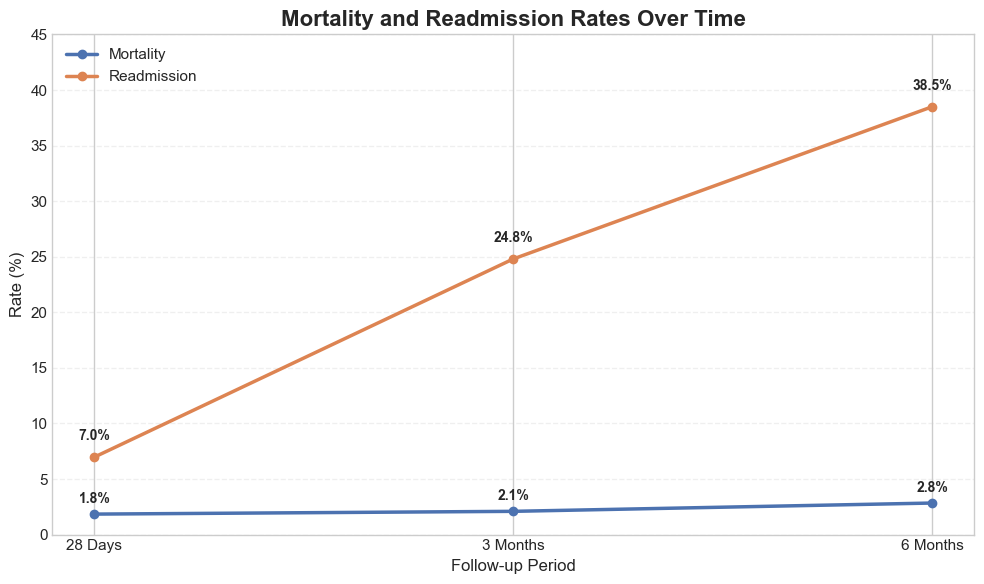

In [82]:
# Time points
time_points = ["28 Days", "3 Months", "6 Months"]

# Rates from your analysis
mortality_rates = [1.842629, 2.091633, 2.838645]
readmission_rates = [6.972112, 24.800797, 38.496016]

# Create figure
plt.figure(figsize=(10, 6))

# Plot mortality
plt.plot(
    time_points,
    mortality_rates,
    marker="o",
    linewidth=2.5,
    label="Mortality"
)

# Plot readmission
plt.plot(
    time_points,
    readmission_rates,
    marker="o",
    linewidth=2.5,
    label="Readmission"
)

# Add percentage labels
for i, value in enumerate(mortality_rates):
    plt.text(
        i, value + 1,
        f"{value:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

for i, value in enumerate(readmission_rates):
    plt.text(
        i, value + 1.5,
        f"{value:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# Titles and labels
plt.title(
    "Mortality and Readmission Rates Over Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Follow-up Period", fontsize=12)
plt.ylabel("Rate (%)", fontsize=12)

# Formatting
plt.ylim(0, 45)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight :</b> Mortality increased only slightly from 1.8% at 28 days to 2.8% at 6 months, while readmission increased substantially from 7.0% to 38.5%,
indicating that readmission was much more common than mortality and increased considerably over the follow-up period